In [1]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [2]:
# Patch the built-in open function to default to UTF-8
import builtins

# Save the original open function
_original_open = builtins.open

def utf8_open(file, mode='r', buffering=-1, encoding=None, errors=None, 
              newline=None, closefd=True, opener=None):
    # Force UTF-8 encoding for text mode files when encoding is not specified
    if 't' in str(mode) or encoding is None:
        if encoding is None:
            encoding = 'utf-8'
    return _original_open(file, mode, buffering, encoding, errors, newline, closefd, opener)

# Replace the built-in open
builtins.open = utf8_open



from convokit import Corpus, Speaker, Utterance, Conversation
from collections import Counter

In [3]:
DATA_FOLDER = "./dataset/question-evasion"
corpus = Corpus(DATA_FOLDER)
corpus.print_summary_stats()

Number of Speakers: 5
Number of Utterances: 6896
Number of Conversations: 3448


In [ ]:
from convokit import FightingWords

d:\Projects\PhD\Course\question-evasion\.venv\Lib\site-packages\convokit\coordination\coordination.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [6]:
binary_labels = {
    "clear_reply": ["Explicit"],
    "dodging": ["Dodging"],
}

coarse_labels = {
    "clear_reply:":["Explicit"],
    "ambivalent:":["Implicit", "Dodging", "General", "Deflection", "Partial"],
    "clear_non_reply:":["Declining", "Ignorance", "Clarification"],
}

fine_labels = {
    "explicit:":["Explicit"],
    "implicit:":["Implicit"],
    "dodging:":["Dodging"],
    "general:":["General"],
    "deflection:":["Deflection"],
    "partial:":["Partial"],
    "declining:":["Declining"],
    "ignorance:":["Ignorance"],
    "clarification:":["Clarification"],
}

In [ ]:
def get_fighting_words_with_ngram(ngram, class1_func, class2_func, class1_name, class2_name):
    fw = FightingWords(ngram_range=(ngram,ngram))
    fw.fit(corpus, class1_func=class1_func, class2_func=class2_func)
    df = fw.summarize(corpus, plot=True, class1_name=class1_name, class2_name=class2_name)
    return fw,df


Initializing default CountVectorizer with ngram_range (1, 1)... Done.
class1_func returned 1052 valid corpus components. class2_func returned 706 valid corpus components.
Vocab size is 2670
Comparing language...
ngram zscores computed.


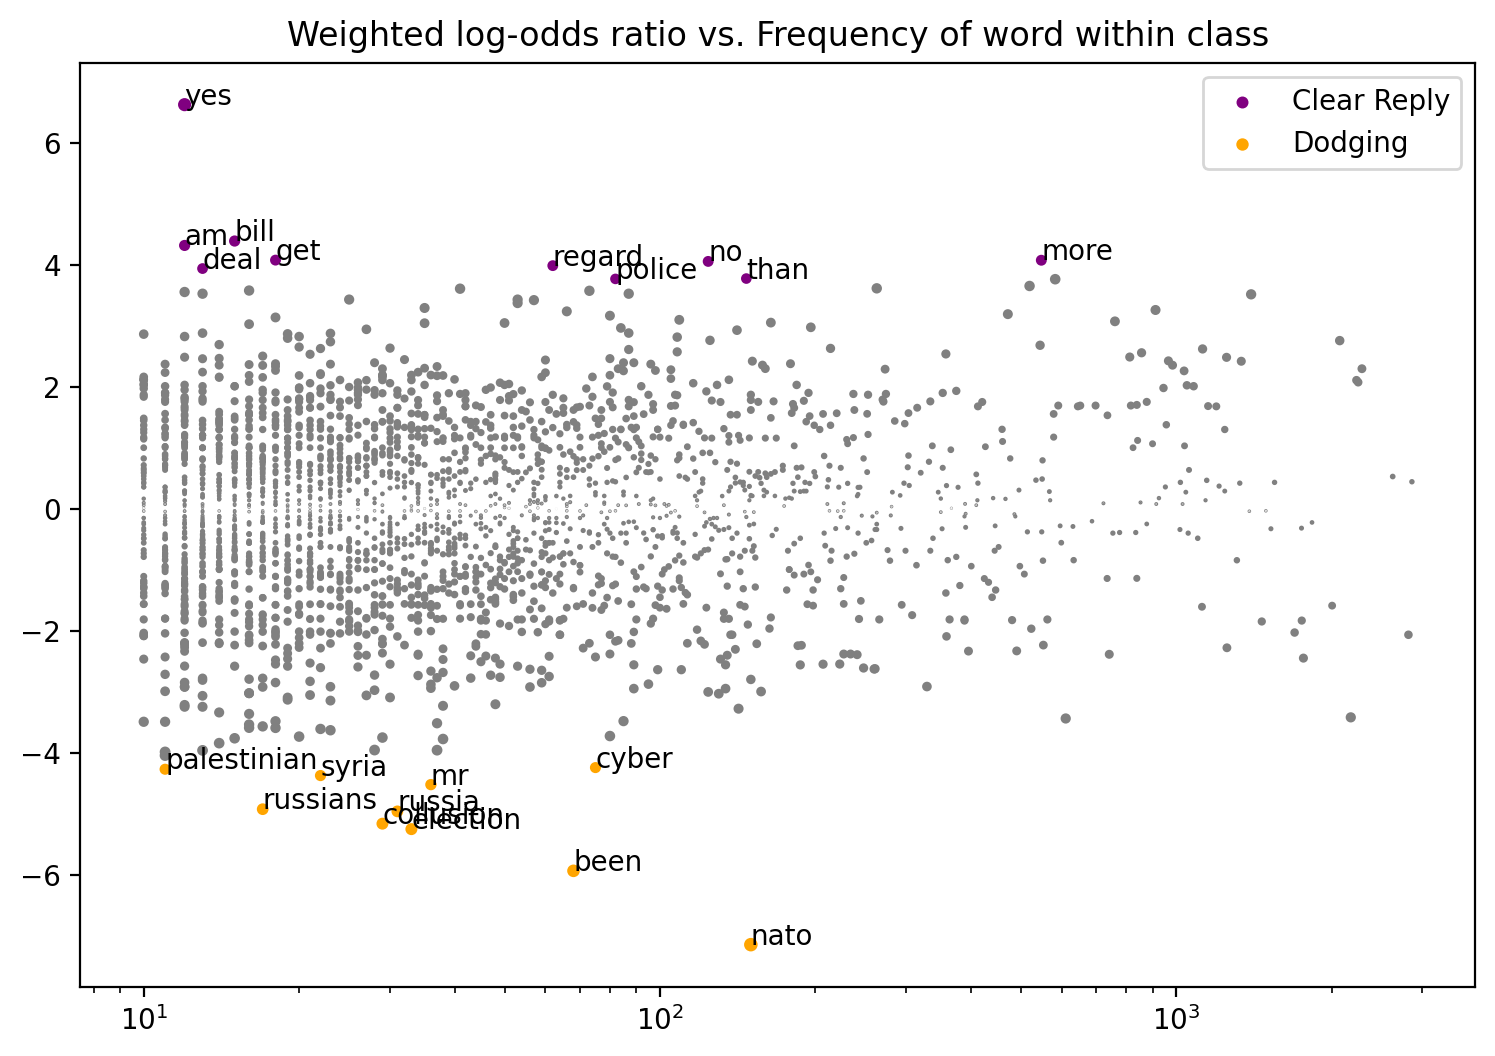

Initializing default CountVectorizer with ngram_range (2, 2)... Done.
class1_func returned 1052 valid corpus components. class2_func returned 706 valid corpus components.
Vocab size is 5928
Comparing language...
ngram zscores computed.


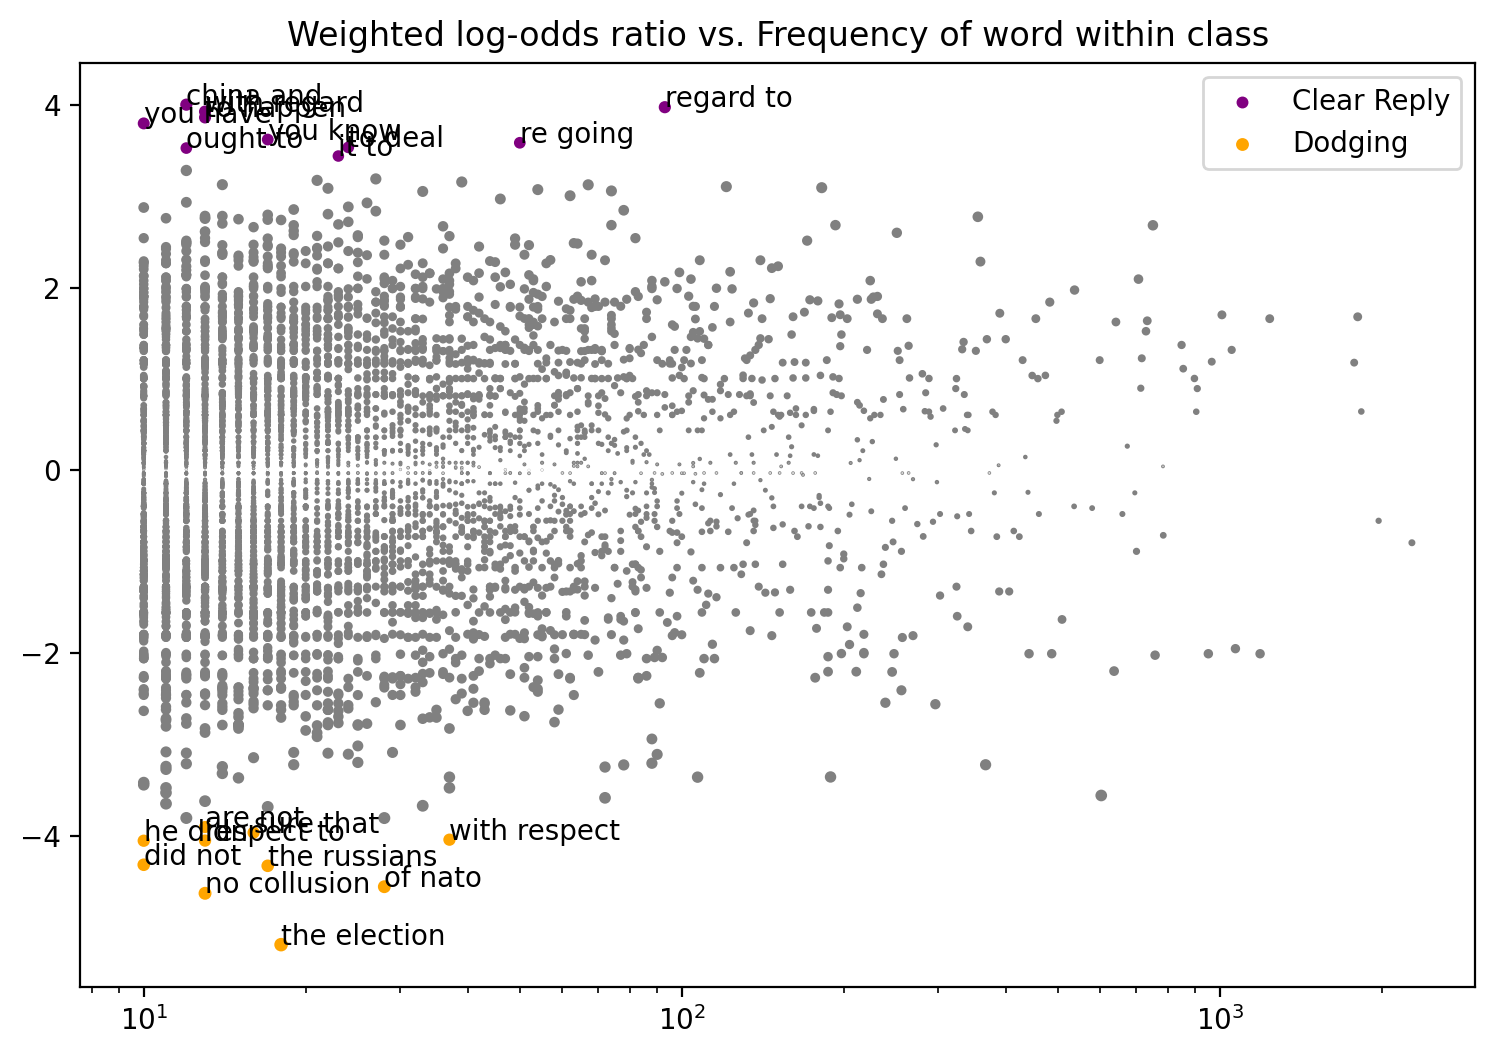

Initializing default CountVectorizer with ngram_range (3, 3)... Done.
class1_func returned 1052 valid corpus components. class2_func returned 706 valid corpus components.
Vocab size is 2837
Comparing language...
ngram zscores computed.


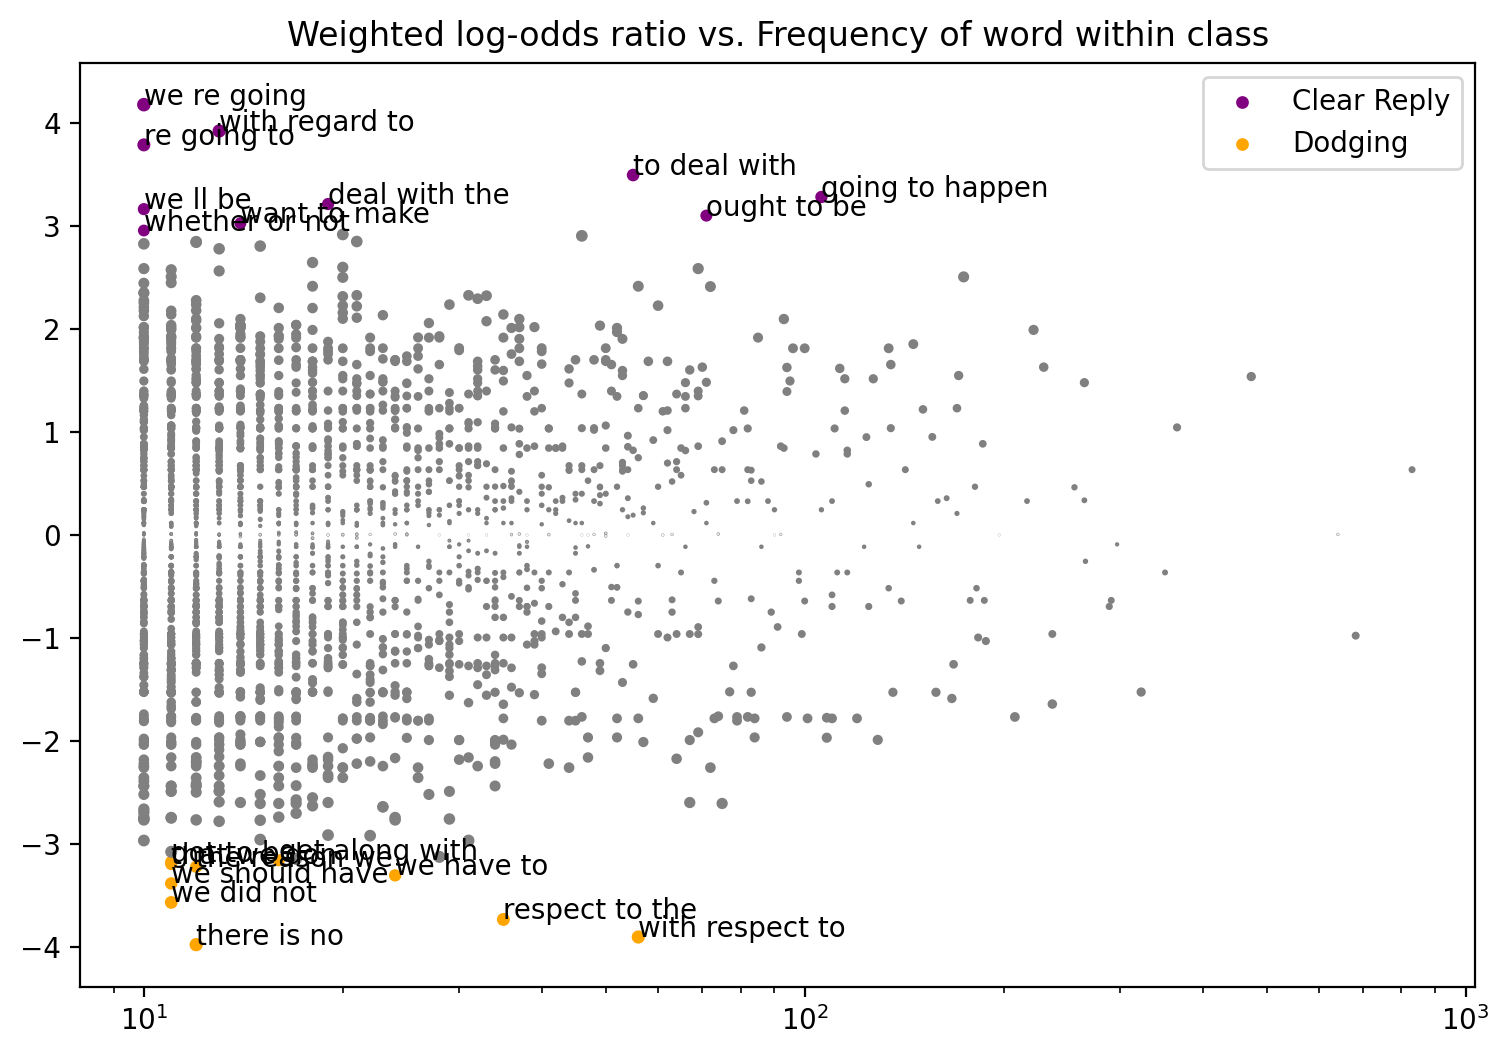

Initializing default CountVectorizer with ngram_range (4, 4)... Done.
class1_func returned 1052 valid corpus components. class2_func returned 706 valid corpus components.
Vocab size is 736
Comparing language...
ngram zscores computed.


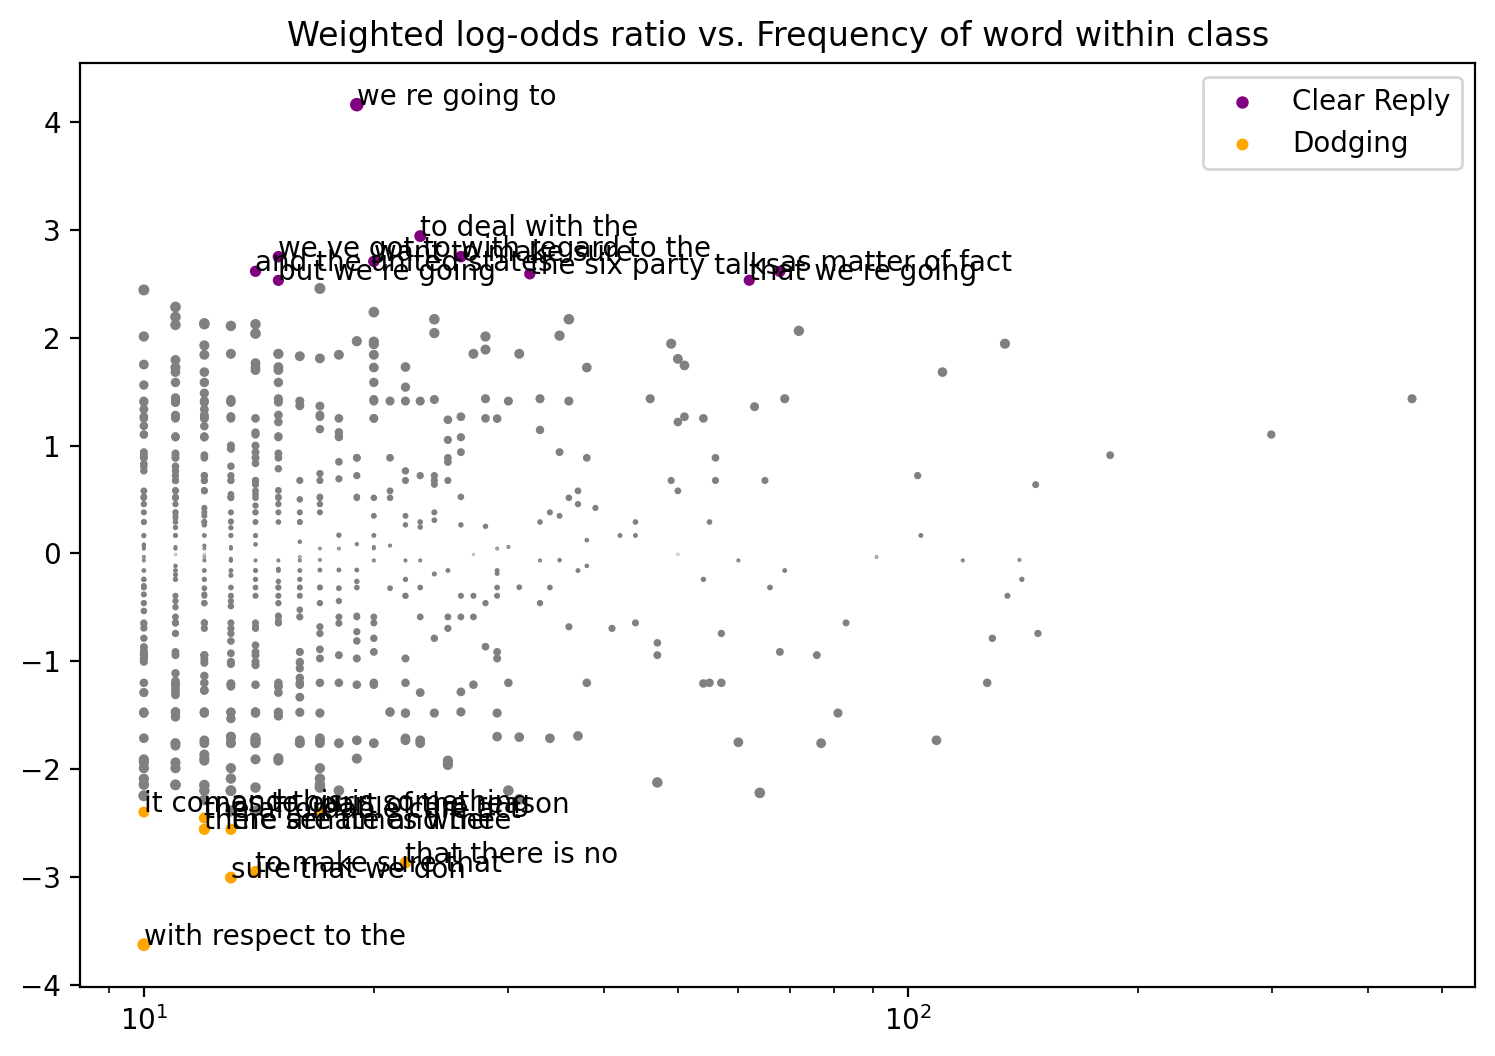

Initializing default CountVectorizer with ngram_range (5, 5)... Done.
class1_func returned 1052 valid corpus components. class2_func returned 706 valid corpus components.
Vocab size is 187
Comparing language...
ngram zscores computed.


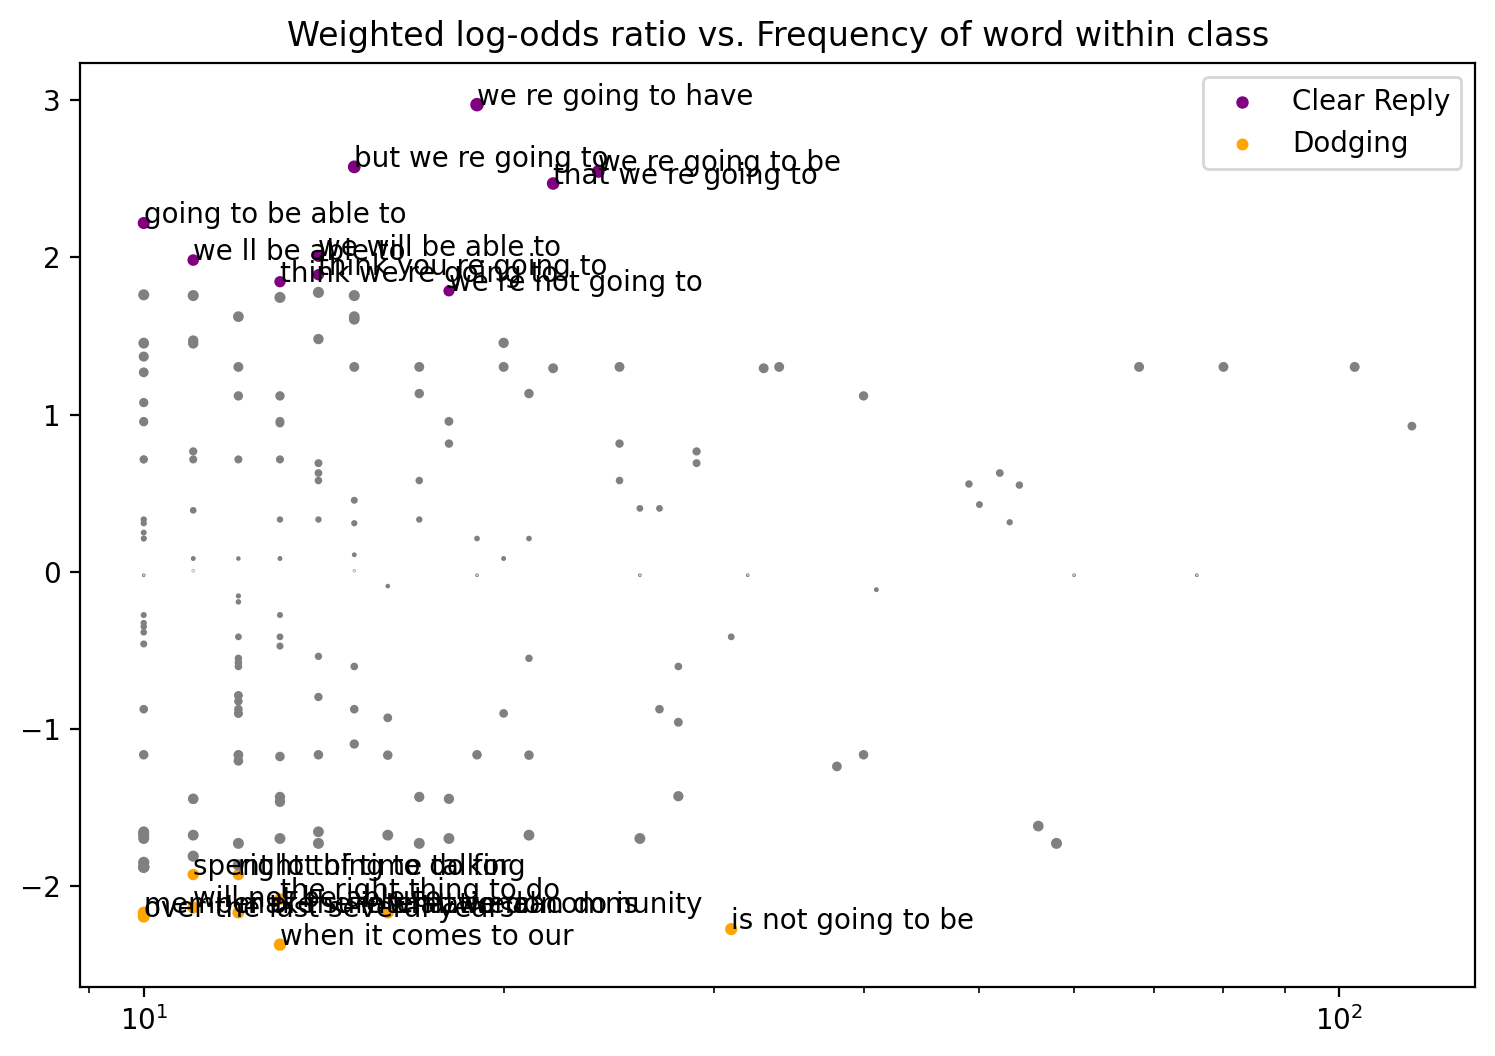

In [ ]:
fw_n_1 = FightingWords(ngram_range=(1,1))
fw_n_1.fit(corpus, class1_func=lambda x: x.meta.get("label") in binary_labels["clear_reply"], class2_func=lambda x: x.meta.get("label") in binary_labels["dodging"])
df_n_1 = fw_n_1.summarize(corpus, plot=True, class1_name="Clear Reply", class2_name="Dodging")

fw_n_2 = FightingWords(ngram_range=(2,2))
fw_n_2.fit(corpus, class1_func=lambda x: x.meta.get("label") in binary_labels["clear_reply"], class2_func=lambda x: x.meta.get("label") in binary_labels["dodging"])
df_n_2 = fw_n_2.summarize(corpus, plot=True, class1_name="Clear Reply", class2_name="Dodging")

fw_n_3 = FightingWords(ngram_range=(3,3))
fw_n_3.fit(corpus, class1_func=lambda x: x.meta.get("label") in binary_labels["clear_reply"], class2_func=lambda x: x.meta.get("label") in binary_labels["dodging"])
df_n_3 = fw_n_3.summarize(corpus, plot=True, class1_name="Clear Reply", class2_name="Dodging")

fw_n_4 = FightingWords(ngram_range=(4,4))
fw_n_4.fit(corpus, class1_func=lambda x: x.meta.get("label") in binary_labels["clear_reply"], class2_func=lambda x: x.meta.get("label") in binary_labels["dodging"])
df_n_4 = fw_n_4.summarize(corpus, plot=True, class1_name="Clear Reply", class2_name="Dodging")

fw_n_5 = FightingWords(ngram_range=(5,5))
fw_n_5.fit(corpus, class1_func=lambda x: x.meta.get("label") in binary_labels["clear_reply"], class2_func=lambda x: x.meta.get("label") in binary_labels["dodging"])
df_n_5 = fw_n_5.summarize(corpus, plot=True, class1_name="Clear Reply", class2_name="Dodging")


In [ ]:
c1, c2 = fw_n_3.get_ngrams_past_threshold(threshold=1)

In [ ]:
df_n_5

,z-score,class
ngram,,
when it comes to our,-2.370506,Dodging
is not going to be,-2.271720,Dodging
over the last several years,-2.192343,Dodging
make sure that we don,-2.166622,Dodging
what we can do is,-2.166622,Dodging
...,...,...
going to be able to,2.218008,Clear Reply
that we re going to,2.469141,Clear Reply
we re going to be,2.545716,Clear Reply


In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from scipy import sparse

def build_sentence_matrix(sentences, fighting_words_models):
    mats = []
    for prefix, fw in fighting_words_models:
        df = fw.get_ngram_zscores(class1_name="class1", class2_name="class2")
        vocab = fw.cv.get_feature_names_out()
        zscores = np.array([df.loc[token, "z-score"] if token in df.index else 0.0 for token in vocab], dtype=np.float32)
        cleaned = [fw.clean_text(sent) for sent in sentences]  
        counts = fw.cv.transform(cleaned)                  
        mats.append(counts.multiply(zscores))                 

    return sparse.hstack(mats, format="csr")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

fighting_words_models = [
    ("n1", fw_n_1),
    ("n2", fw_n_2),
    # ("n3", fw_n_3),
    # ("n4", fw_n_4),
    # ("n5", fw_n_5),
]

In [ ]:
# sentences + labels (same as before)
texts, labels = [], []
for utt in corpus.iter_utterances():
    label = utt.meta.get("label")
    if label in binary_labels["clear_reply"] + binary_labels["dodging"]:
        texts.append(utt.text)
        labels.append("Clear Reply" if label in binary_labels["clear_reply"] else "Dodging")

X_all = build_sentence_matrix(texts, fighting_words_models)
y_all = np.array(labels)

X_train_all, X_val_all, y_train_all, y_val_all = train_test_split(
    X_all, y_all, stratify=y_all, test_size=0.2, random_state=42
)

clf_all = LogisticRegression(class_weight="balanced", solver="liblinear", max_iter=1000)
clf_all.fit(X_train_all, y_train_all)
print("Combined model accuracy:", clf_all.score(X_val_all, y_val_all))

Combined model accuracy: 0.6619318181818182


In [ ]:
def evaluate_single_fw(prefix, fw):
    X_block = build_sentence_matrix(texts, [(prefix, fw)])
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_block, y_all, stratify=y_all, test_size=0.2, random_state=42
    )
    clf = LogisticRegression(class_weight="balanced", solver="liblinear", max_iter=1000)
    clf.fit(X_tr, y_tr)
    return clf.score(X_val, y_val)

for prefix, fw in fighting_words_models:
    acc = evaluate_single_fw(prefix, fw)
    print(f"{prefix} only accuracy: {acc:.3f}")

n1 only accuracy: 0.628
n2 only accuracy: 0.636
n3 only accuracy: 0.602
n4 only accuracy: 0.534
n5 only accuracy: 0.494


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

labels = np.array(labels)
classes, counts = np.unique(labels, return_counts=True)
probs = counts / counts.sum()

rng = np.random.default_rng(42)
y_random = rng.choice(classes, size=len(labels), p=probs)
print("Random baseline accuracy:", accuracy_score(labels, y_random))

Random baseline accuracy: 0.5142207053469852


In [4]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split



In [9]:
entity_types = ["PERSON", "ORG", "GPE", "NORP", "DATE", "TIME", "MONEY", "FAC", "LAW", "EVENT", "LOC", "PRODUCT", "LANGUAGE", ]

texts, labels = [], []
for utt in corpus.iter_utterances():
    label = utt.meta.get("label")
    if label in binary_labels["clear_reply"] + binary_labels["dodging"]:
        texts.append(utt.text)
        labels.append("Clear Reply" if label in binary_labels["clear_reply"] else "Dodging")

def ner_matrix(texts):
    data = np.zeros((len(texts), len(entity_types)), dtype=np.float32)
    for i, doc in enumerate(nlp.pipe(texts, batch_size=64)):
        counts = {ent.label_: 0 for ent in doc.ents}
        for ent in doc.ents:
            if ent.label_ in counts:
                counts[ent.label_] += 1
        for j, label in enumerate(entity_types):
            data[i, j] = counts.get(label, 0)
    return data

X_ner = ner_matrix(texts)
y = np.array(labels)

X_train, X_val, y_train, y_val = train_test_split(X_ner, y, stratify=y, test_size=0.2, random_state=42)

clf = LogisticRegression(class_weight="balanced", solver="liblinear", max_iter=1000)
clf.fit(X_train, y_train)
print("NER-based validation accuracy:", clf.score(X_val, y_val))

NER-based validation accuracy: 0.4630681818181818


In [8]:
import pandas as pd

coef_ner = pd.Series(clf.coef_[0], index=entity_types).sort_values(ascending=False)

print("Top weights → predict Clear Reply")
print(coef_ner.head(10))

print("\nTop weights → predict Dodging")
print(coef_ner.tail(10))

Top weights → predict Clear Reply
LANGUAGE    0.119984
PRODUCT     0.073849
ORDINAL     0.050761
ORG         0.022323
GPE         0.011179
NORP        0.007478
LAW         0.000401
LOC        -0.026035
DATE       -0.026748
PERSON     -0.027889
dtype: float64

Top weights → predict Dodging
DATE          -0.026748
PERSON        -0.027889
CARDINAL      -0.036068
EVENT         -0.049916
MONEY         -0.068043
FAC           -0.096438
PERCENT       -0.279756
TIME          -0.429482
WORK_OF_ART   -0.567277
QUANTITY      -1.186264
dtype: float64
